# AI Image Understanding System

This project demonstrates how deep learning models can understand images using CNN feature extraction and transformer-based caption generation.

In [34]:
!pip install torch torchvision
!pip install transformers
!pip install opencv-python
!pip install matplotlib
!pip install gradio

In [ ]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

import cv2
import numpy as np
import matplotlib.pyplot as plt

from transformers import pipeline
from google.colab import files

## STEP 1: Upload Image

In [ ]:
uploaded = files.upload()

Saving car.jpg to car (1).jpg


## STEP 2: Display Image

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

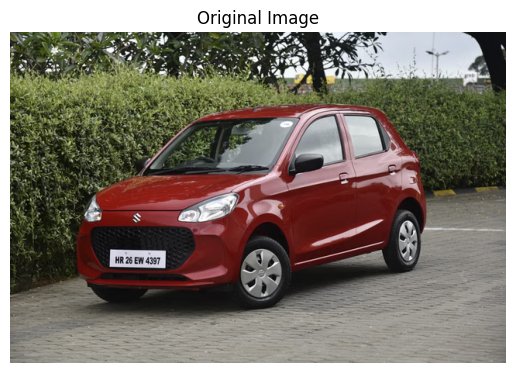

In [ ]:
image = cv2.imread("car.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

## STEP 3: Edge Detection using OpenCV

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

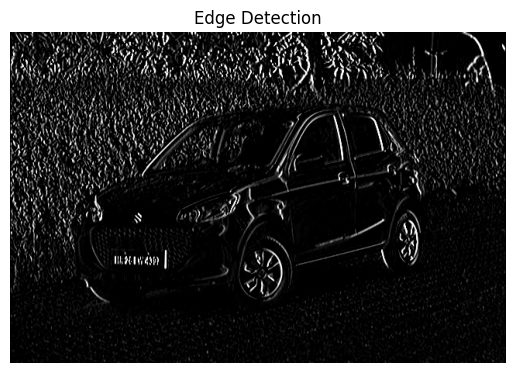

In [ ]:
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

kernel = np.array([
[1,0,-1],
[1,0,-1],
[1,0,-1]
])

edges = cv2.filter2D(gray,-1,kernel)

plt.imshow(edges,cmap='gray')
plt.title("Edge Detection")
plt.axis("off")

## STEP 4: CNN Feature Extraction

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv1 = nn.Conv2d(3,16,3)
        self.conv2 = nn.Conv2d(16,32,3)

        self.pool = nn.MaxPool2d(2,2)

    def forward(self,x):

        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        return x

model = CNN()

In [ ]:
transform = transforms.Compose([
transforms.ToTensor(),
transforms.Resize((64,64))
])

img_tensor = transform(image).unsqueeze(0)

In [ ]:
features = model(img_tensor)

print("Feature Map Shape:",features.shape)

Feature Map Shape: torch.Size([1, 32, 14, 14])


## STEP 5: CNN Feature Visualization

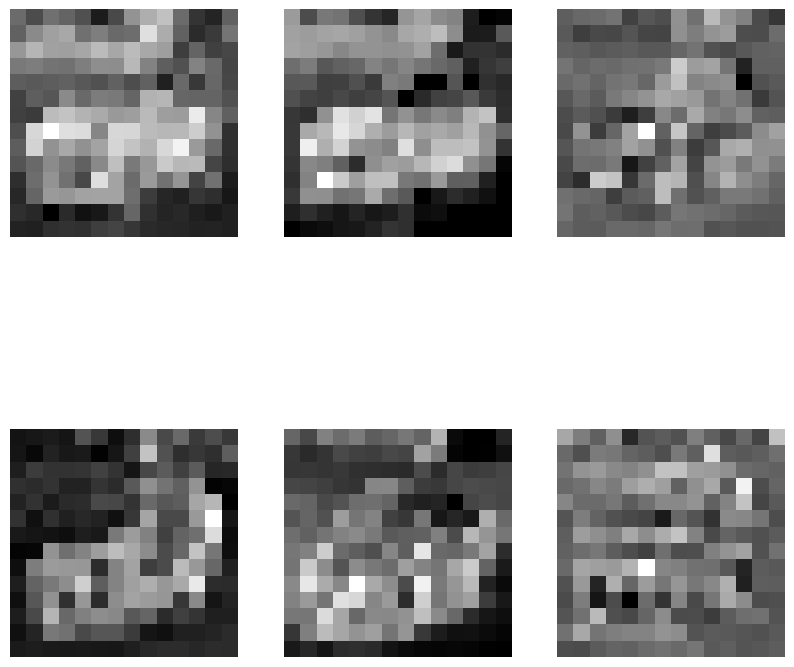

In [ ]:
feature_maps = features.detach().numpy()[0]

plt.figure(figsize=(10,10))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(feature_maps[i],cmap='gray')
    plt.axis("off")

plt.show()

## STEP 6: Image Caption Generation using BLIP Transformer

In [ ]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

pil_image = Image.fromarray(image)

inputs = processor(pil_image, return_tensors="pt")

out = model.generate(**inputs)

caption = processor.decode(out[0], skip_special_tokens=True)

print("Generated Caption:", caption)

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Generated Caption: a red car parked on a brick road


In [32]:
import gradio as gr
import cv2
import numpy as np
from PIL import Image

def analyze_image(img):

    image = np.array(img)

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    kernel = np.array([
        [1,0,-1],
        [1,0,-1],
        [1,0,-1]
    ])

    edges = cv2.filter2D(gray,-1,kernel)

    pil_image = Image.fromarray(image)

    inputs = processor(pil_image, return_tensors="pt")
    out = model.generate(**inputs)

    caption = processor.decode(out[0], skip_special_tokens=True)

    return edges, caption

In [33]:
interface = gr.Interface(
    fn=analyze_image,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Image(label="Edge Detection"),
        gr.Textbox(label="Generated Caption")
    ],
    title="AI Image Analyzer",
    description="Upload an image and AI will analyze it"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://dd14a088de086f3d17.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Conclusion

This project demonstrates an AI-based image understanding system.

The workflow of the system is:

1. The user uploads an image.
2. OpenCV is used to perform edge detection on the image.
3. A Convolutional Neural Network (CNN) extracts visual features from the image.
4. The extracted feature maps are visualized to understand what the CNN learns.
5. A BLIP transformer-based model generates a natural language caption describing the image.

Technologies Used:
- Python
- PyTorch
- OpenCV
- Transformers (BLIP)
- Google Colab

This shows how computer vision and transformer models can work together to analyze and understand images.